In [ ]:
import pandas as pd
df = pd.read_csv("kaggle_survey_2017_2021.csv")
print(df.head())

/tmp/ipython-input-2585853315.py:2: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,26

      - Time from Start to Finish (seconds)                           Q1  \
0  Year               Duration (in seconds)  What is your age (# years)?   
1  2021                                 910                        50-54   
2  2021                                 784                        50-54   
3  2021                                 924                        22-24   
4  2021                                 575                        45-49   

                                       Q2  \
0  What is your gender? - Selected Choice   
1                                     Man   
2                                     Man   
3                                     Man   
4                                     Man   

                                          Q3  \
0  In which country do you currently reside?   
1                                      India   
2                                  Indonesia   
3                                   Pakistan   
4                               

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106302 entries, 0 to 106301
Columns: 293 entries, - to Q38_B_OTHER
dtypes: object(293)
memory usage: 237.6+ MB


In [ ]:
df.describe()

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
count,106302,89586,105857,106207,106181,103319,99088,92786,65943,20885,...,2212,2761,1128,1022,7439,1287,1218,1186,1,629
unique,7,12778,12,10,78,13,36,21,2,2,...,2,2,2,2,2,2,2,2,1,2
top,2021,394,25-29,Male,India,Masterâ€™s degree,Student,3-5 years,Python,R,...,Neptune.ai,Weights & Biases,Comet.ml,Sacred + Omniboard,TensorBoard,Guild.ai,Polyaxon,Domino Model Monitor,"In the next 2 years, do you hope to become mor...",Other
freq,23926,105,23748,49178,25192,37395,21242,15995,65942,20884,...,2211,2760,1127,1021,7438,1286,1217,1185,1,628


In [ ]:
df.isnull().sum()

,0
-,0
Time from Start to Finish (seconds),16716
Q1,445
Q2,95
Q3,121
...,...
Q38_B_Part_6,105015
Q38_B_Part_7,105084
Q38_B_Part_9,105116
Q38_B_Part_11,106301


In [ ]:
df.duplicated().sum()

np.int64(4456)

In [ ]:
df.shape

(106302, 293)

In [ ]:
df = df.drop_duplicates()
print(df.shape)

(101846, 293)


In [ ]:
null_values = df.isnull().mean()
df = df.loc[:,null_values<0.7]
print(df.shape)

(101846, 30)


In [ ]:
df.columns

Index(['-', 'Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4',
       'Q5', 'Q6', 'Q7_Part_1', 'Q7_Part_3', 'Q8', 'Q9_Part_1', 'Q11', 'Q13',
       'Q14_Part_1', 'Q14_Part_2', 'Q15', 'Q16_Part_1', 'Q16_Part_2',
       'Q17_Part_1', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24_Part_1', 'Q25', 'Q26',
       'Q40_Part_1', 'Q41', 'Q42_Part_4'],
      dtype='object')

In [ ]:
columns_needed = ["Q1","Q2","Q3","Q4","Q5","Q6",
                  "Q7_Part_1","Q7_Part_3"]

df_clean = df[columns_needed]

print(df_clean.head())

                            Q1                                      Q2  \
0  What is your age (# years)?  What is your gender? - Selected Choice   
1                        50-54                                     Man   
2                        50-54                                     Man   
3                        22-24                                     Man   
4                        45-49                                     Man   

                                          Q3  \
0  In which country do you currently reside?   
1                                      India   
2                                  Indonesia   
3                                   Pakistan   
4                                     Mexico   

                                                  Q4  \
0  What is the highest level of formal education ...   
1                                Bachelorâ€™s degree   
2                                  Masterâ€™s degree   
3                                  Masterâ

In [ ]:
df = df.fillna({"Q2":"Not specified"})
df = df.fillna({"Q3":"Unknown"})

In [ ]:
df_clean["Q2"].value_counts()

,count
Q2,
Male,45220
Man,36368
Female,9560
Woman,8768
Prefer not to say,1276
Prefer to self-describe,224
A different identity,153
Nonbinary,140
"Non-binary, genderqueer, or gender non-conforming",74


In [ ]:
df_clean["Q3"].value_counts()

,count
Q3,
India,23936
United States of America,12682
Other,5532
China,3502
Russia,3299
...,...
Uganda,47
Kazakhstan,45
Ethiopia,43


In [ ]:
df_clean["Q4"].value_counts()

,count
Q4,
Masterâ€™s degree,37391
Bachelorâ€™s degree,29952
Doctoral degree,13146
Master's degree,4933
Some college/university study without earning a bachelorâ€™s degree,4631
Bachelor's degree,3474
Professional degree,2350
I prefer not to answer,1787
No formal education past high school,1122


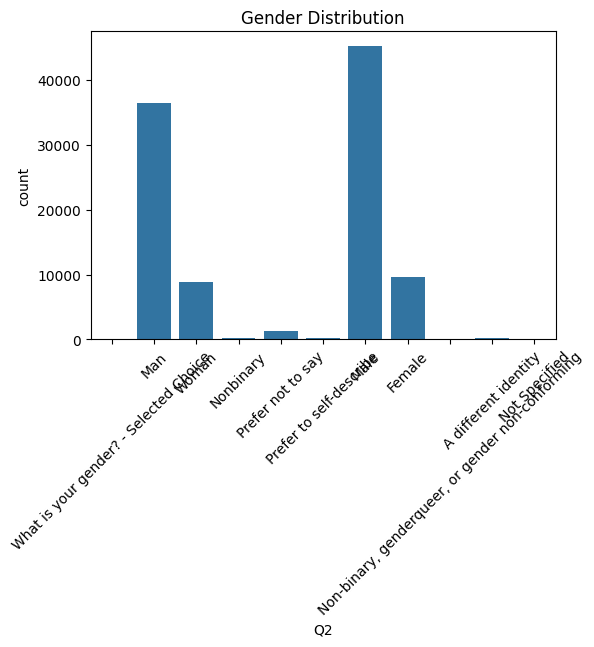

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Q2")
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load dataset (assumed combined 2017–2021 Kaggle survey)
df = pd.read_csv("kaggle_survey_2017_2021.csv")

# Preprocessing:
# Rename the first column from '-' to 'Year'
df.rename(columns={df.columns[0]: 'Year'}, inplace=True)

# Drop the row with full question text (row 0) and make a copy to avoid SettingWithCopyWarning
df_cleaned = df.iloc[1:].copy()

# Ensure 'Year' column is numeric for plotting trends
df_cleaned['Year'] = pd.to_numeric(df_cleaned['Year'])

# Dummy column to count respondents
df_cleaned['Respondent'] = 1

# 1. Programming Language Usage Across Years (using Q7_Part_X columns)
# Identify all Q7_Part_X columns that exist in df_cleaned
q7_columns = [col for col in df_cleaned.columns if col.startswith('Q7_Part_')]

# Create a DataFrame for language trends by melting the Q7_Part_X columns
# This will create rows for each language mentioned by a respondent
lang_melted = df_cleaned[['Year'] + q7_columns].melt(id_vars=['Year'], var_name='Q_Part_Column', value_name='Language_Worked_With')

# Filter out NaN values (where no language was selected for that Q_Part)
lang_melted = lang_melted[lang_melted['Language_Worked_With'].notna()]

# Now group by Year and Language_Worked_With to count respondents
lang_trends = lang_melted.groupby(['Year', 'Language_Worked_With'])['Q_Part_Column'].count().reset_index()
lang_trends.rename(columns={'Q_Part_Column': 'Respondent'}, inplace=True)

fig1 = px.line(lang_trends, x='Year', y='Respondent', color='Language_Worked_With',
               title="Programming Language Usage Across Years")

# 2. Education level changes (using Q4 for FormalEducation)
edu_trends = df_cleaned.groupby(['Year', 'Q4'])['Respondent'].count().reset_index()
edu_trends.rename(columns={'Q4': 'FormalEducation'}, inplace=True)
fig2 = px.area(edu_trends, x='Year', y='Respondent', color='FormalEducation',
               title="Education Level Distribution Over Time")

# 3. Job role distribution (using Q5 for JobRoleInterest)
role_trends = df_cleaned.groupby(['Year', 'Q5'])['Respondent'].count().reset_index()
role_trends.rename(columns={'Q5': 'JobRoleInterest'}, inplace=True)
fig3 = px.bar(role_trends, x='Year', y='Respondent', color='JobRoleInterest',
              title="Job Role Trends Over Time")

# 4. Experience levels (using Q6 for YearsCoding)
exp_trends = df_cleaned.groupby(['Year', 'Q6'])['Respondent'].count().reset_index()
exp_trends.rename(columns={'Q6': 'YearsCoding'}, inplace=True)
fig4 = px.line(exp_trends, x='Year', y='Respondent', color='YearsCoding',
               title="Experience Levels Over Years")

# 5. Visualizing machine learning model use (using Q17_Part_1 for MLTechniques - assuming ML Frameworks)
# Similar to languages, if there were multiple Q17_Part_X columns, we could melt them.
# For simplicity, we'll track Q17_Part_1 values.
ml_tech_usage = df_cleaned[df_cleaned['Q17_Part_1'].notna()].groupby(['Year', 'Q17_Part_1'])['Respondent'].count().reset_index()
ml_tech_usage.rename(columns={'Q17_Part_1': 'MLTechniques'}, inplace=True)
fig5 = px.line(ml_tech_usage, x='Year', y='Respondent', color='MLTechniques',
               title="Machine Learning Framework Popularity Over Time")

# Show all
fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()

/tmp/ipython-input-2409970606.py:6: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,26